In [70]:
import os
import sys

import pandas as pd
import numpy as np

work_dir = "/home/handb/GeoSTHN"

os.chdir(work_dir)
sys.path.append(work_dir)

## Archive

In [71]:
import pandas as pd
import numpy as np

dataset = "thgl-github-subset"

# ================= 配置区 =================
EDGE_FILE = f"tgb/DATA/{dataset.replace('-', '_')}/{dataset}_edgelist.csv"
NODE_FILE = f"tgb/DATA/{dataset.replace('-', '_')}/{dataset}_nodetype.csv"
# =========================================
t_col = "timestamp"
src_col = "head"
dst_col = "tail"
rel_col = "relation_type"

print("🔄 正在加载数据...")

# 1. 加载边列表
# 假设CSV没有表头，通常TGB格式为: [timestamp, source_id, destination_id, edge_type/weight]
# 如果你的文件有表头，请将 header=None 改为 header=0
df_edges = pd.read_csv(EDGE_FILE)
df_edges = df_edges.rename(
    columns={
        t_col: "ts",
        src_col: "src",
        dst_col: "dst",
        rel_col: "rel",
    }
)

# 2. 加载节点类型映射
df_nodes = pd.read_csv(NODE_FILE)
node_type_map = dict(zip(df_nodes["node_id"], df_nodes["type"]))


print(f"✅ 数据加载完毕: {len(df_edges)} 条边, {len(df_nodes)} 个节点")

# ================= 核心逻辑：寻找“有故事”的节点 =================

# 1. 划分时间段 (前20% vs 后20%)
t_min, t_max = df_edges["ts"].min(), df_edges["ts"].max()
duration = t_max - t_min
t_split_early = t_min + duration * 0.2
t_split_late = t_max - duration * 0.2

print(f"🕒 时间跨度: {t_min:.1f} -> {t_max:.1f}")

# 2. 统计每个节点在不同阶段的度 (交互次数)
# 这里我们将 src 和 dst 都视为交互参与者
all_nodes = pd.concat([df_edges["src"], df_edges["dst"]])
total_degree = all_nodes.value_counts()

# 早期阶段 (Early Stage)
early_edges = df_edges[df_edges["ts"] <= t_split_early]
early_nodes = pd.concat([early_edges["src"], early_edges["dst"]])
early_degree = early_nodes.value_counts()

# 晚期阶段 (Late Stage)
late_edges = df_edges[df_edges["ts"] >= t_split_late]
late_nodes = pd.concat([late_edges["src"], late_edges["dst"]])
late_degree = late_nodes.value_counts()

# ================= 筛选策略 =================

candidates = []

# 策略 A: "超级中枢" (Global Hubs) - 总交互量最高
print("\n🏆 --- 候选人榜单 A: 超级中枢 (总活跃度最高) ---")
top_hubs = total_degree.head(20).index.tolist()
for nid in top_hubs:
    ntype = node_type_map.get(nid, "Unknown")
    count = total_degree[nid]
    print(f"  👉 ID: {nid} | 类型: {ntype} | 总交互: {count}")
    candidates.append(nid)

# 策略 B: "后期之秀" (Rising Stars) - 后期活跃度远大于早期
print("\n🚀 --- 候选人榜单 B: 后期之秀 (爆发式增长) ---")
# 计算增长量：晚期度 - 早期度 (填充0以防报错)
growth_score = late_degree.subtract(early_degree, fill_value=0)
top_rising = growth_score.sort_values(ascending=False).head(5).index.tolist()

for nid in top_rising:
    ntype = node_type_map.get(nid, "Unknown")
    late_c = late_degree.get(nid, 0)
    early_c = early_degree.get(nid, 0)
    # 过滤掉那些本来就很强只是变得更强的，我们想要“从无到有”的
    if early_c < 50:
        print(
            f"  👉 ID: {nid} | 类型: {ntype} | 早期: {early_c} -> 晚期: {late_c} (增长: +{int(late_c - early_c)})"
        )
        candidates.append(nid)

print("\n💡 建议：")
print("1. 如果你想展示模型捕捉'层次结构'的能力，请从榜单 A 中选一个 Repo 节点。")
print("2. 如果你想展示模型捕捉'动态演化'的能力，请从榜单 B 中选一个增长最显著的节点。")

🔄 正在加载数据...
✅ 数据加载完毕: 50000 条边, 36818 个节点
🕒 时间跨度: 1709269200.0 -> 1709278348.0

🏆 --- 候选人榜单 A: 超级中枢 (总活跃度最高) ---
  👉 ID: 38 | 类型: 2 | 总交互: 3573
  👉 ID: 142 | 类型: 2 | 总交互: 2121
  👉 ID: 8 | 类型: 2 | 总交互: 1646
  👉 ID: 58 | 类型: 2 | 总交互: 1355
  👉 ID: 976 | 类型: 2 | 总交互: 307
  👉 ID: 19 | 类型: 2 | 总交互: 276
  👉 ID: 456 | 类型: 1 | 总交互: 164
  👉 ID: 32 | 类型: 2 | 总交互: 148
  👉 ID: 34 | 类型: 1 | 总交互: 148
  👉 ID: 454 | 类型: 2 | 总交互: 144
  👉 ID: 2200 | 类型: 1 | 总交互: 108
  👉 ID: 2198 | 类型: 2 | 总交互: 108
  👉 ID: 515 | 类型: 2 | 总交互: 90
  👉 ID: 1461 | 类型: 2 | 总交互: 70
  👉 ID: 7502 | 类型: 2 | 总交互: 70
  👉 ID: 4099 | 类型: 2 | 总交互: 69
  👉 ID: 6996 | 类型: 1 | 总交互: 67
  👉 ID: 807 | 类型: 2 | 总交互: 57
  👉 ID: 31855 | 类型: 2 | 总交互: 54
  👉 ID: 955 | 类型: 1 | 总交互: 53

🚀 --- 候选人榜单 B: 后期之秀 (爆发式增长) ---
  👉 ID: 31855 | 类型: 2 | 早期: 0 -> 晚期: 54 (增长: +54)
  👉 ID: 515 | 类型: 2 | 早期: 8 -> 晚期: 50 (增长: +42)
  👉 ID: 31678 | 类型: 1 | 早期: 0 -> 晚期: 32 (增长: +32)
  👉 ID: 24870 | 类型: 1 | 早期: 0 -> 晚期: 27 (增长: +27)

💡 建议：
1. 如果你想展示模型捕捉'层次结构'的能力，请从榜单 A 中选

In [ ]:
import numpy as np
import pandas as pd
import os

dataset = "thgl-github-subset"

# ================= 配置区 =================
# 请修改为你实际的文件路径
FILE_PATHS = {
    "node_ids": f"exper/rq7/{dataset}/output/run_0/{dataset}_test_nodes.npz",  # 存储 batch_src_node_ids 的文件
    "timestamps": f"exper/rq7/{dataset}/output/run_0/{dataset}_test_times.npz",  # 存储 batch_time_ids 的文件
    "degrees": f"exper/rq7/{dataset}/output/run_0/{dataset}_test_degrees.npz",  # 存储 batch_degrees 的文件 (可选)
    "embeddings": f"exper/rq7/{dataset}/output/run_0/{dataset}_test_hs.npz",  # 存储 embeddings 的文件
}

TARGET_NODE_ID = 38
OUTPUT_FILE = f"rq6/data/case_study_node_{TARGET_NODE_ID}_cleaned.csv"

ids_list = np.load(FILE_PATHS["node_ids"], allow_pickle=True)["nodes"]
time_list = np.load(FILE_PATHS["timestamps"], allow_pickle=True)["times"]
emb_list = np.load(FILE_PATHS["embeddings"], allow_pickle=True)["hs"]
deg_list = np.load(FILE_PATHS["degrees"], allow_pickle=True)["degrees"]


# 3. 核心循环：提取数据
tgt_time_list = []
tgt_emb_list = []
tgt_deg_list = []
num_batches = len(ids_list)
for i in range(num_batches):
    b_ids = ids_list[i]
    b_time = time_list[i]
    b_emb = emb_list[i]
    b_deg = deg_list[i]
    for idx, (node_id_src, node_id_dst) in enumerate(zip(b_ids[0], b_ids[1])):
        if node_id_src == TARGET_NODE_ID:
            ts = b_time[0][idx]
            emb = b_emb[: len(b_emb) // 2][idx]
            deg = b_deg[0][idx]
            tgt_time_list.append(ts)
            tgt_emb_list.append(emb)
            tgt_deg_list.append(deg)
        if node_id_dst == TARGET_NODE_ID:
            ts = b_time[1][idx]
            emb = b_emb[len(b_emb) // 2 :][idx]
            deg = b_deg[1][idx]
            tgt_time_list.append(ts)
            tgt_emb_list.append(emb)
            tgt_deg_list.append(deg)

检测到 Lorentz 坐标，正在投影到 Poincaré 圆盘...
✅ 图 A 已生成: case_study_trajectory.png
✅ 图 B 已生成: case_study_correlation.png


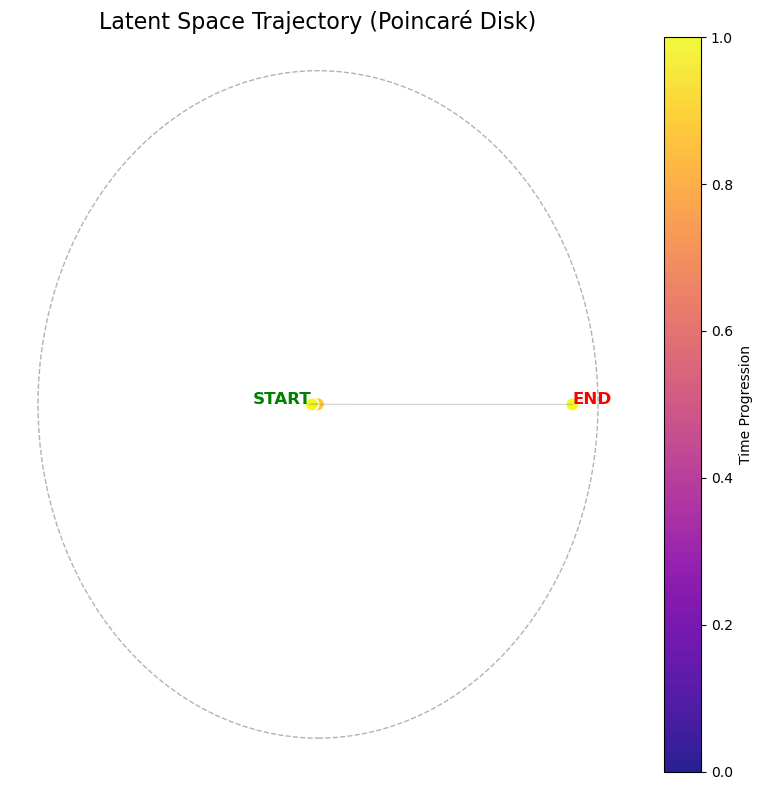

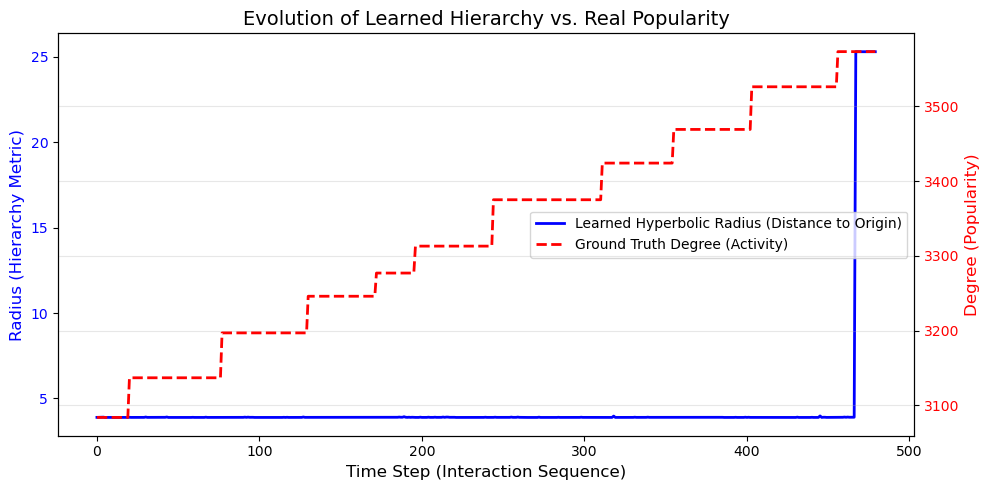

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 转换成 numpy 数组方便处理
times = np.array(tgt_time_list)
embs = np.array(tgt_emb_list)
degs = np.array(tgt_deg_list)

# ================= 2. 数据预处理 =================

# A. 归一化时间 (用于上色)
# 把时间映射到 0~1 之间
time_norm = (times - times.min()) / (times.max() - times.min() + 1e-9)


# B. 空间映射 (Lorentz -> Poincaré Ball)
# 你的模型可能是 Lorentz 模型，为了画在圆盘上，需要投影
def project_to_ball(z):
    # 计算每个向量的模长
    norms = np.linalg.norm(z, axis=1)
    # 如果模长普遍很大，说明是双曲面(Lorentz)，需要投影
    if norms.mean() > 1.2:
        print("检测到 Lorentz 坐标，正在投影到 Poincaré 圆盘...")
        # 公式: ball_coord = space_part / (time_part + 1)
        # 假设第0维是时间维 x0
        x0 = z[:, 0]
        x_space = z[:, 1:]
        denominator = x0 + 1
        denominator[denominator == 0] = 1e-5
        return x_space / denominator[:, None]
    else:
        print("检测到 Poincaré 坐标，保持不变...")
        return z


z_ball = project_to_ball(embs)

# C. 降维 (用于画轨迹)
# 如果维度大于2，用PCA压扁到2维
if z_ball.shape[1] > 2:
    pca = PCA(n_components=2)
    z_plot = pca.fit_transform(z_ball)
    # 稍微缩放一下确保在圆内 (PCA可能会破坏单位圆约束，为了视觉美观微调)
    max_r = np.max(np.linalg.norm(z_plot, axis=1))
    if max_r > 0.95:
        z_plot = z_plot / (max_r * 1.1)
else:
    z_plot = z_ball

# D. 计算双曲半径 (代表层级/地位)
# 在庞加莱球中，半径 r 越小 (越靠近圆心 0)，地位越高 (Degree 越大)
radii = np.linalg.norm(z_ball, axis=1)


# ================= 3. 画图 A: 庞加莱圆盘轨迹图 =================
plt.figure(figsize=(8, 8))
ax = plt.gca()

# 画背景圆
circle = plt.Circle((0, 0), 1.0, color="black", fill=False, linestyle="--", alpha=0.3)
ax.add_artist(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

# 画轨迹线 (灰色细线)
plt.plot(z_plot[:, 0], z_plot[:, 1], color="gray", alpha=0.3, linewidth=1)

# 画散点 (颜色代表时间：深色=早期，亮色=晚期)
sc = plt.scatter(
    z_plot[:, 0],
    z_plot[:, 1],
    c=time_norm,
    cmap="plasma",
    s=80,
    alpha=0.9,
    edgecolors="white",
    linewidth=0.5,
)

# 标注起点和终点
plt.text(
    z_plot[0, 0],
    z_plot[0, 1],
    "START",
    fontsize=12,
    fontweight="bold",
    color="green",
    ha="right",
)
plt.text(
    z_plot[-1, 0],
    z_plot[-1, 1],
    "END",
    fontsize=12,
    fontweight="bold",
    color="red",
    ha="left",
)

plt.title("Latent Space Trajectory (Poincaré Disk)", fontsize=16)
plt.colorbar(sc, label="Time Progression")
plt.axis("off")
plt.tight_layout()
plt.savefig("case_study_trajectory.png", dpi=300)
print("✅ 图 A 已生成: case_study_trajectory.png")


# ================= 4. 画图 B: 影响力验证图 (核心证据) =================
# 这张图用来证明：你的模型学到的“半径”真的能反映“真实度数”
plt.figure(figsize=(10, 5))
ax1 = plt.gca()

# X轴：时间步
x_steps = range(len(times))

# 左轴 (蓝色)：双曲半径
# 我们希望看到它下降 (从边缘走向中心)
line1 = ax1.plot(
    x_steps,
    radii,
    "b-",
    linewidth=2,
    label="Learned Hyperbolic Radius (Distance to Origin)",
)
ax1.set_xlabel("Time Step (Interaction Sequence)", fontsize=12)
ax1.set_ylabel("Radius (Hierarchy Metric)", color="b", fontsize=12)
ax1.tick_params(axis="y", labelcolor="b")

# 右轴 (红色)：真实度数
# 我们希望看到它上升 (变得越来越活跃)
ax2 = ax1.twinx()
line2 = ax2.plot(
    x_steps, degs, "r--", linewidth=2, label="Ground Truth Degree (Activity)"
)
ax2.set_ylabel("Degree (Popularity)", color="r", fontsize=12)
ax2.tick_params(axis="y", labelcolor="r")

# 合并图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Evolution of Learned Hierarchy vs. Real Popularity", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("case_study_correlation.png", dpi=300)
print("✅ 图 B 已生成: case_study_correlation.png")

plt.show()

🌌 检测到 Lorentz 坐标，正在投影...
📉 正在降维到 2D...
✅ 美化版轨迹图已保存: case_study_trajectory_beautiful.png
✅ 美化版统计图已保存: case_study_stats_beautiful.png


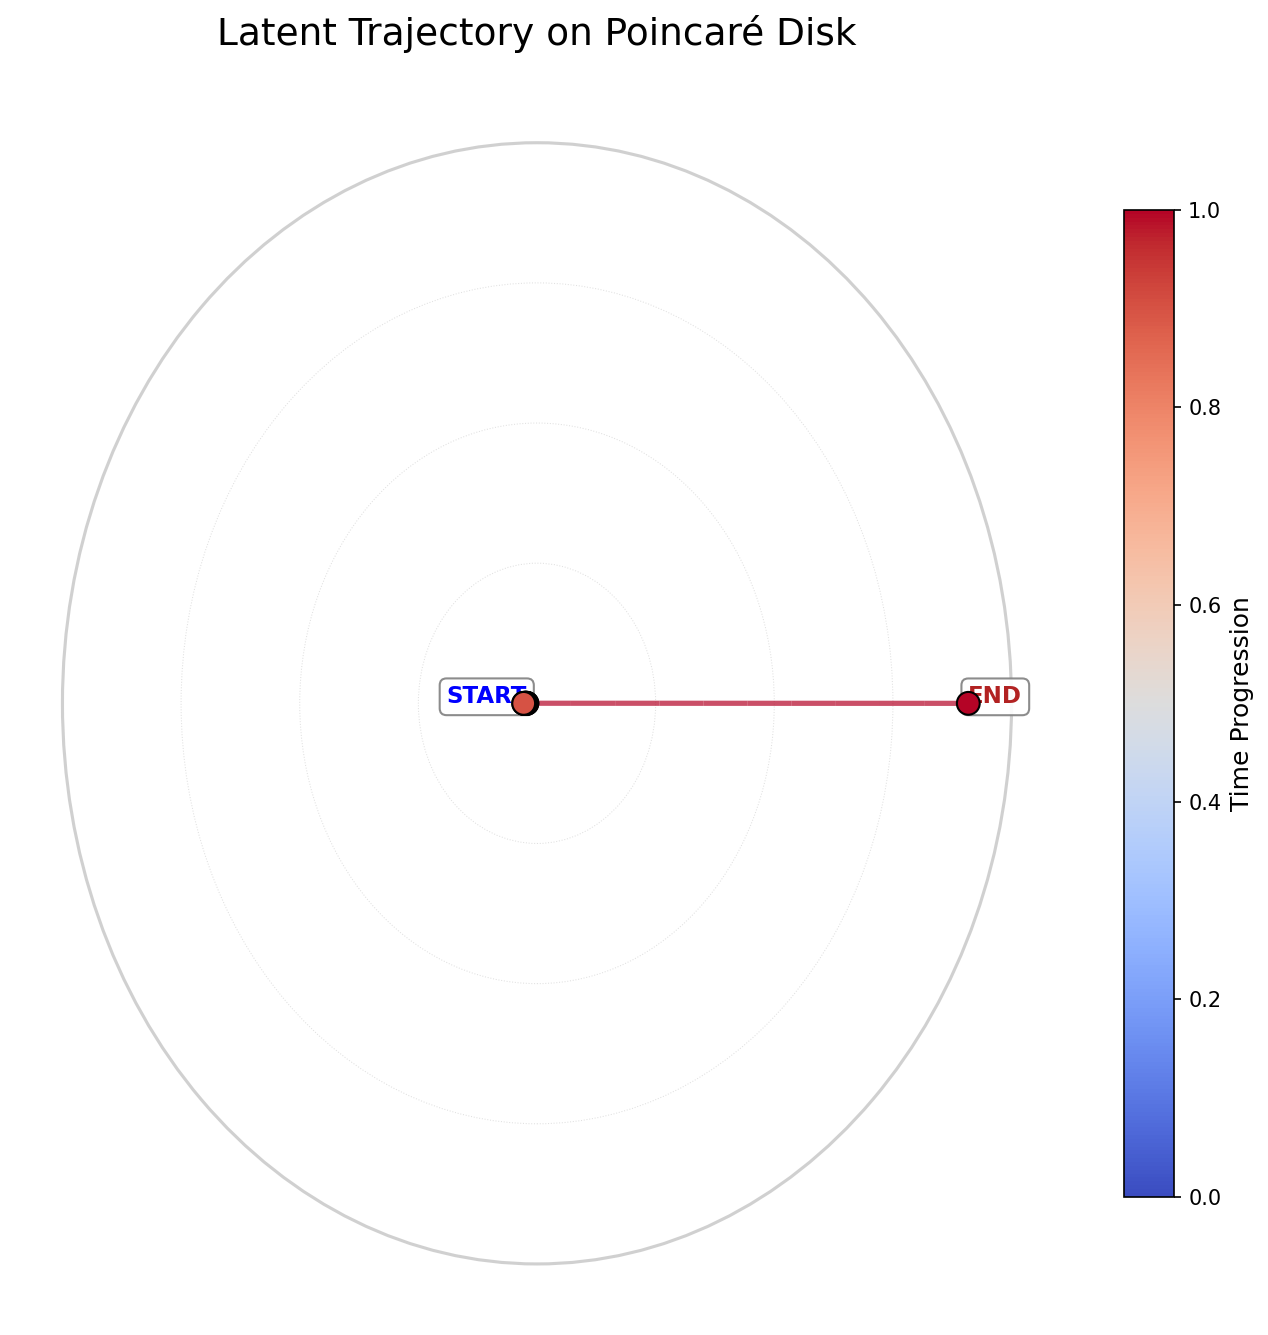

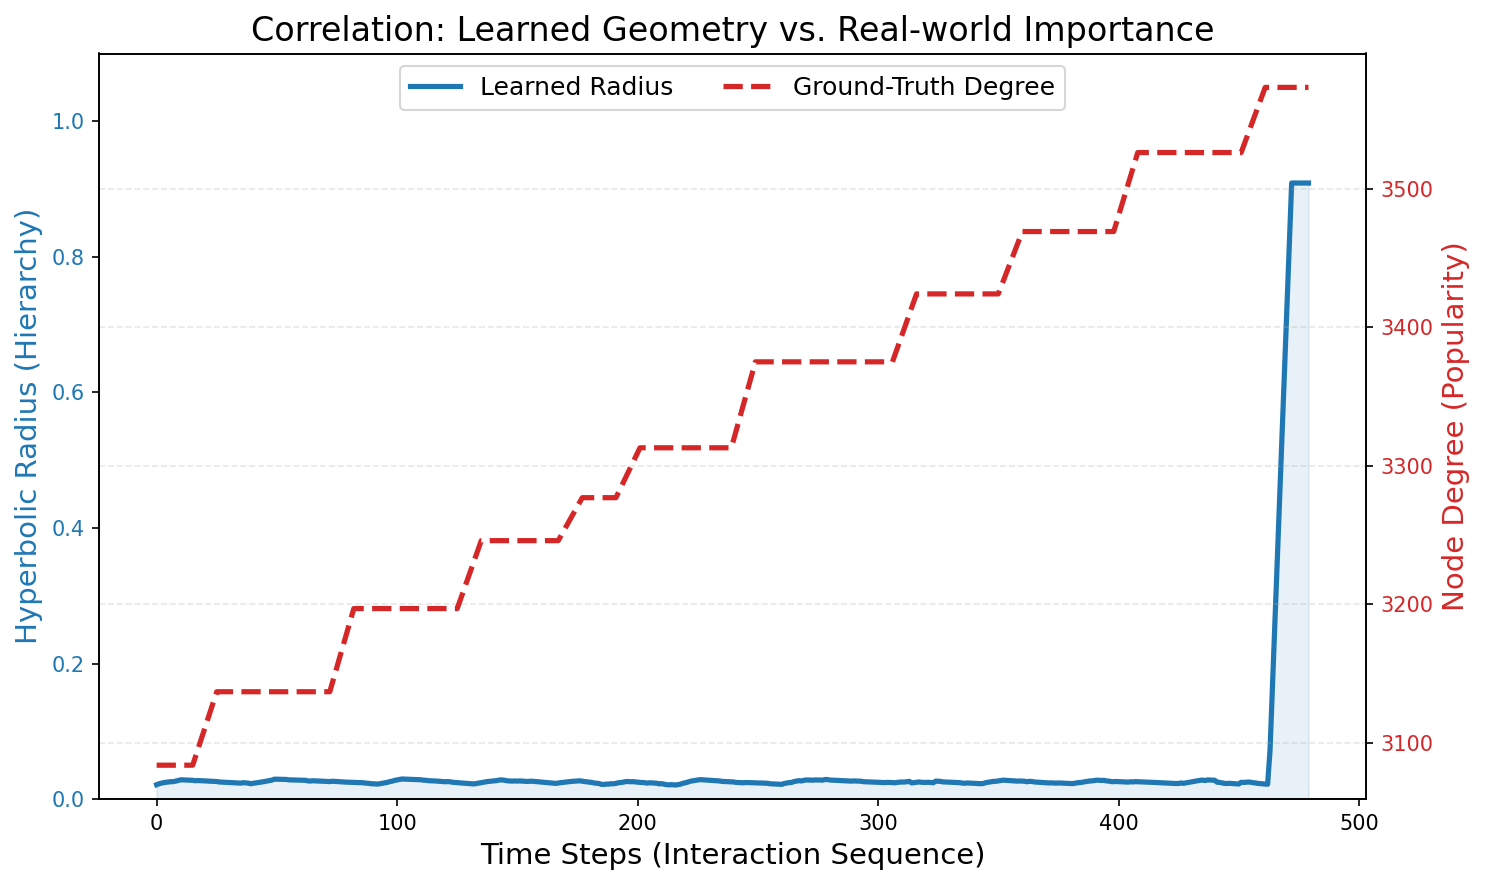

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
import seaborn as sns

# 转换为 Numpy 数组
times = np.array(tgt_time_list)
embs = np.array(tgt_emb_list)
degs = np.array(tgt_deg_list)

# ================= 2. 数据清洗与处理 =================

# A. 归一化时间 (0.0 -> 1.0)
time_norm = (times - times.min()) / (times.max() - times.min() + 1e-9)


# B. 空间映射 (Lorentz -> Poincaré)
def project_to_ball(z):
    norms = np.linalg.norm(z, axis=1)
    if norms.mean() > 1.2:
        print("🌌 检测到 Lorentz 坐标，正在投影...")
        x0 = z[:, 0]
        x_space = z[:, 1:]
        denom = x0 + 1
        denom[denom == 0] = 1e-5
        return x_space / denom[:, None]
    return z


z_ball = project_to_ball(embs)

# C. 降维到 2D
if z_ball.shape[1] > 2:
    print("📉 正在降维到 2D...")
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_ball)
    # 缩放适配：防止 PCA 后的点跑出单位圆
    max_r = np.max(np.linalg.norm(z_2d, axis=1))
    if max_r > 0.95:
        z_2d = z_2d / (max_r * 1.1)
else:
    z_2d = z_ball

# D. 核心美化步骤：轨迹平滑 (Smoothing)
# 这能去除抖动，让线条像丝带一样顺滑
# window_size 越大越平滑，建议 5~15
window_size = 10
z_smooth = (
    pd.DataFrame(z_2d)
    .rolling(window=window_size, min_periods=1, center=True)
    .mean()
    .values
)

# 计算半径 (用于统计图)
radii = np.linalg.norm(z_smooth, axis=1)

# ================= 3. 画图 A: 高级轨迹图 =================
plt.figure(figsize=(9, 9), dpi=150)  # 高分辨率
ax = plt.gca()

# 1. 画漂亮的背景圆
circle_main = plt.Circle(
    (0, 0), 1.0, color="#666666", fill=False, linestyle="-", linewidth=1.5, alpha=0.3
)
circle_grid1 = plt.Circle(
    (0, 0), 0.75, color="#999999", fill=False, linestyle=":", linewidth=0.5, alpha=0.3
)
circle_grid2 = plt.Circle(
    (0, 0), 0.50, color="#999999", fill=False, linestyle=":", linewidth=0.5, alpha=0.3
)
circle_grid3 = plt.Circle(
    (0, 0), 0.25, color="#999999", fill=False, linestyle=":", linewidth=0.5, alpha=0.3
)
ax.add_artist(circle_main)
ax.add_artist(circle_grid1)
ax.add_artist(circle_grid2)
ax.add_artist(circle_grid3)

# 2. 画渐变色轨迹 (Gradient Line)
# 将点转换成线段集合，以便给每一段上不同的颜色
points = z_smooth.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
# 使用 'coolwarm' 色谱：蓝色=早期(冷)，红色=晚期(热)
lc = LineCollection(segments, cmap="coolwarm", norm=plt.Normalize(0, 1), alpha=0.7)
lc.set_array(time_norm)
lc.set_linewidth(2.5)  # 线条稍微粗一点
ax.add_collection(lc)

# 3. 画关键帧散点 (Key Frames)
# 不要画所有点，只画 10-12 个关键点，避免密恐
num_key_frames = 12
indices = np.linspace(0, len(z_smooth) - 1, num_key_frames, dtype=int)
key_z = z_smooth[indices]
key_t = time_norm[indices]

sc = plt.scatter(
    key_z[:, 0],
    key_z[:, 1],
    c=key_t,
    cmap="coolwarm",
    s=120,
    edgecolors="black",
    linewidth=1.0,
    zorder=10,
)

# 4. 标注起点和终点 (带背景框，更清晰)
bbox_style = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
plt.text(
    z_smooth[0, 0],
    z_smooth[0, 1],
    "START",
    fontsize=11,
    fontweight="bold",
    color="blue",
    ha="right",
    bbox=bbox_style,
)
plt.text(
    z_smooth[-1, 0],
    z_smooth[-1, 1],
    "END",
    fontsize=11,
    fontweight="bold",
    color="firebrick",
    ha="left",
    bbox=bbox_style,
)

# 5. 修饰
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title("Latent Trajectory on Poincaré Disk", fontsize=18, pad=20)
cbar = plt.colorbar(sc, shrink=0.8, pad=0.05)
cbar.set_label("Time Progression", fontsize=12)
plt.axis("off")  # 隐藏坐标轴
plt.tight_layout()
plt.savefig("case_study_trajectory_beautiful.png", dpi=300)
print("✅ 美化版轨迹图已保存: case_study_trajectory_beautiful.png")


# ================= 4. 画图 B: 统计验证图 =================
plt.figure(figsize=(10, 6), dpi=150)
ax1 = plt.gca()

# X轴
steps = np.arange(len(times))

# 左轴：双曲半径 (用平滑后的数据)
color_r = "tab:blue"
ax1.set_xlabel("Time Steps (Interaction Sequence)", fontsize=14)
ax1.set_ylabel("Hyperbolic Radius (Hierarchy)", color=color_r, fontsize=14)
# 加粗线条，加阴影区域表示趋势
ax1.plot(steps, radii, color=color_r, linewidth=2.5, label="Learned Radius")
ax1.fill_between(steps, radii, alpha=0.1, color=color_r)
ax1.tick_params(axis="y", labelcolor=color_r)
ax1.set_ylim(0, 1.1)  # 半径通常在0-1之间

# 右轴：真实度数
ax2 = ax1.twinx()
color_d = "tab:red"
ax2.set_ylabel("Node Degree (Popularity)", color=color_d, fontsize=14)
# 度数通常波动大，我们也可以稍微平滑一下以便看清趋势
deg_smooth = pd.Series(degs).rolling(window=10, min_periods=1, center=True).mean()
ax2.plot(
    steps,
    deg_smooth,
    color=color_d,
    linestyle="--",
    linewidth=2.5,
    label="Ground-Truth Degree",
)
ax2.tick_params(axis="y", labelcolor=color_d)

# 图例与标题
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", ncol=2, fontsize=12)

plt.title("Correlation: Learned Geometry vs. Real-world Importance", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("case_study_stats_beautiful.png", dpi=300)
print("✅ 美化版统计图已保存: case_study_stats_beautiful.png")

plt.show()

## 绘制3D曲面

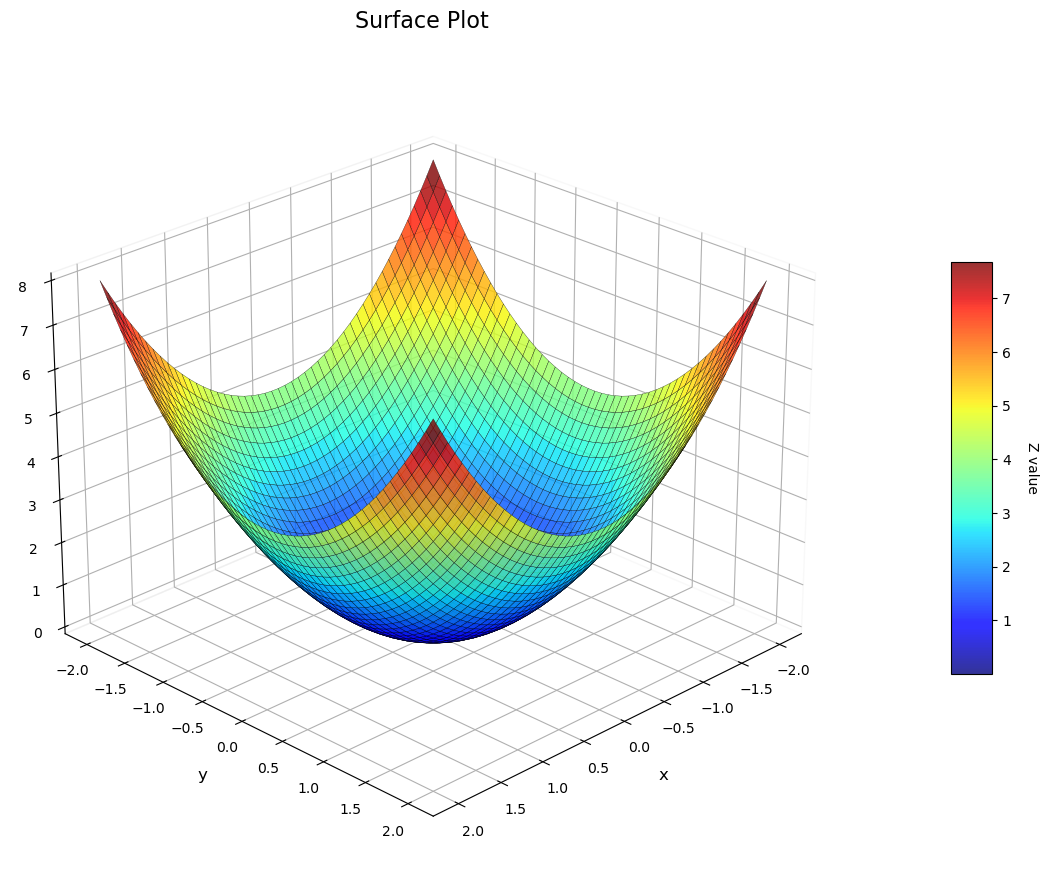

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# 创建数据
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# 创建图形
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# 绘制曲面图（带网格线）
surf = ax.plot_surface(
    X, Y, Z, cmap="jet", linewidth=0.2, edgecolor="black", alpha=0.8, antialiased=True
)

# 美化设置
ax.set_xlabel("x", fontsize=12, labelpad=10)
ax.set_ylabel("y", fontsize=12, labelpad=10)
ax.set_zlabel("z", fontsize=12, labelpad=10)
ax.set_title("Surface Plot", fontsize=16, pad=20)

# 添加颜色条
cbar = fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label("Z value", rotation=270, labelpad=20)

# 设置视角
ax.view_init(elev=25, azim=45)

# 设置背景
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()
plt.show()

✅ 透明背景、无图例的蓝色曲面图已保存: surface_uniform_blue_transparent.png


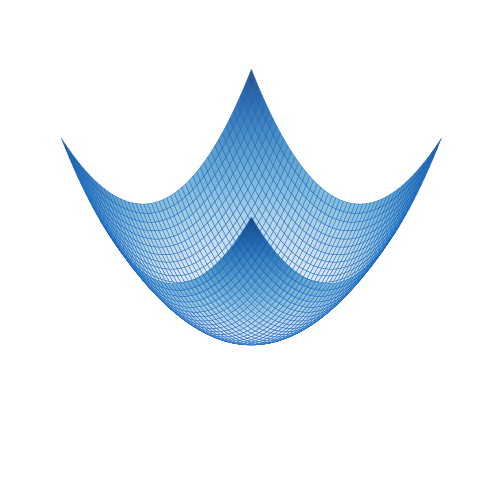

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# 创建数据
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# 创建图形
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")

# 绘制曲面图（统一淡蓝色渐变，深度由Z值决定）
surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="Blues",  # 统一蓝色渐变
    linewidth=0.3,
    edgecolor="#1565C0",  # 深蓝色网格线
    alpha=0.85,
    antialiased=True,
    vmin=Z.min(),  # 确保颜色映射从最小值开始
    vmax=Z.max(),  # 到最大值结束
)

# ================= 隐藏所有坐标轴 =================
# 隐藏坐标轴标签
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")

# 隐藏刻度
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# 隐藏坐标轴线和背景网格
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")

# 隐藏网格
ax.grid(False)

# 隐藏坐标轴线
ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))

# 完全隐藏坐标轴
ax.axis("off")

# ================= 设置视角 =================
ax.view_init(elev=25, azim=135)  # 向右旋转90度

# ================= 不添加颜色条（已注释掉）=================
# cbar = fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)
# cbar.set_label("Depth", rotation=270, labelpad=20, color="#1565C0")
# cbar.ax.tick_params(colors="#1565C0")

plt.tight_layout()

# ================= 保存为透明背景 =================
plt.savefig(
    "surface_uniform_blue_transparent.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,  # 透明背景
    pad_inches=0.1,
)
print("✅ 透明背景、无图例的蓝色曲面图已保存: surface_uniform_blue_transparent.png")
plt.show()

## 抽查节点信息

In [74]:
dataset = "thgl-github-subset"

EDGE_FILE = f"tgb/DATA/{dataset.replace('-', '_')}/{dataset}_edgelist.csv"
NODE_FILE = f"tgb/DATA/{dataset.replace('-', '_')}/{dataset}_nodetype.csv"
t_col = "timestamp"
src_col = "head"
dst_col = "tail"
rel_col = "relation_type"

df_edges = pd.read_csv(EDGE_FILE)
df_edges = df_edges.rename(
    columns={
        t_col: "ts",
        src_col: "src",
        dst_col: "dst",
        rel_col: "rel",
    }
)
df_nodes = pd.read_csv(NODE_FILE)
node_type_map = dict(zip(df_nodes["node_id"], df_nodes["type"]))

In [81]:
node_id = 38  # 替换为你选择的节点ID

node_type_map_str = {0: "issue", 1: "repo", 2: "user", 3: "pr"}
df_edges["src_type"] = df_edges["src"].map(node_type_map)
df_edges["dst_type"] = df_edges["dst"].map(node_type_map)
df_edges["src_type_str"] = df_edges["src_type"].map(node_type_map_str)
df_edges["dst_type_str"] = df_edges["dst_type"].map(node_type_map_str)
df_edges.drop(columns=["src_type", "dst_type"], inplace=True)
df_edges_single = df_edges[(df_edges["src"] == node_id) | (df_edges["dst"] == node_id)]
print("node_id type:", df_edges_single.iloc[0]["src_type_str"])
print(f"node_id: {node_id}\n", df_edges_single["dst_type_str"].value_counts())

node_id type: user
node_id: 38
 dst_type_str
pr    3573
Name: count, dtype: int64


In [83]:
df_edges[df_edges["dst_type_str"] == "repo"]

,ts,src,dst,rel,src_type_str,dst_type_str
0,1709269200,0,1,0,issue,repo
2,1709269200,3,4,2,issue,repo
4,1709269202,6,7,4,pr,repo
6,1709269203,9,10,4,pr,repo
8,1709269204,12,13,4,pr,repo
...,...,...,...,...,...,...
49992,1709278345,36815,18077,4,pr,repo
49994,1709278345,35229,35230,6,pr,repo
49995,1709278346,36816,22660,4,pr,repo
49997,1709278347,36320,36321,13,issue,repo


In [68]:
from pyvis.network import Network
import os

# 配置节点类型颜色
node_type_colors = {
    "issue": "#FF6B6B",  # 红色
    "repo": "#4ECDC4",  # 青色
    "user": "#FFE66D",  # 黄色
    "pr": "#95E1D3",  # 绿色
}

# 创建交互式网络（修复版本）
net = Network(
    height="800px",
    width="100%",
    bgcolor="#ffffff",
    font_color="black",
    directed=True,
    notebook=False,  # 关键修复：明确指定不在notebook模式
)

# 配置物理引擎
net.barnes_hut(
    gravity=-5000,
    central_gravity=0.3,
    spring_length=200,
    spring_strength=0.05,
    damping=0.09,
)

# 添加节点和边
for _, row in df_edges.iterrows():
    # 添加源节点
    net.add_node(
        int(row["src"]),  # 确保ID是整数
        label=f"{row['src']}\n({row['src_type_str']})",
        color=node_type_colors[row["src_type_str"]],
        title=f"ID: {row['src']}<br>Type: {row['src_type_str']}",
        size=25,
        shape="dot",
    )

    # 添加目标节点
    net.add_node(
        int(row["dst"]),
        label=f"{row['dst']}\n({row['dst_type_str']})",
        color=node_type_colors[row["dst_type_str"]],
        title=f"ID: {row['dst']}<br>Type: {row['dst_type_str']}",
        size=25,
        shape="dot",
    )

    # 添加边
    net.add_edge(
        int(row["src"]),
        int(row["dst"]),
        title=f"Relation: {row['rel']}<br>Time: {row['ts']}",
        arrows="to",
        width=2,
    )

# 保存为HTML文件
output_file = f"aux-exp/RQ6/data/node_interactive.html"

# 方法1：使用 save_graph（推荐）
try:
    net.save_graph(output_file)
    print(f"✅ 交互式网络图已保存: {output_file}")
    print(f"   请打开文件: {os.path.abspath(output_file)}")
except Exception as e:
    print(f"❌ 保存失败: {e}")
    # 方法2：手动写入HTML
    print("   尝试备用方案...")
    html_content = net.generate_html()
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(html_content)
    print(f"✅ 使用备用方案保存成功: {output_file}")

✅ 交互式网络图已保存: aux-exp/RQ6/data/node_interactive.html
   请打开文件: /home/handb/GeoSTHN/aux-exp/RQ6/data/node_interactive.html


/tmp/ipykernel_3359894/2419212929.py:54: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color, label=node_type, edgecolor="black", linewidth=1.5)


✅ 静态网络图已保存: aux-exp/RQ6/data/node_38_network.png


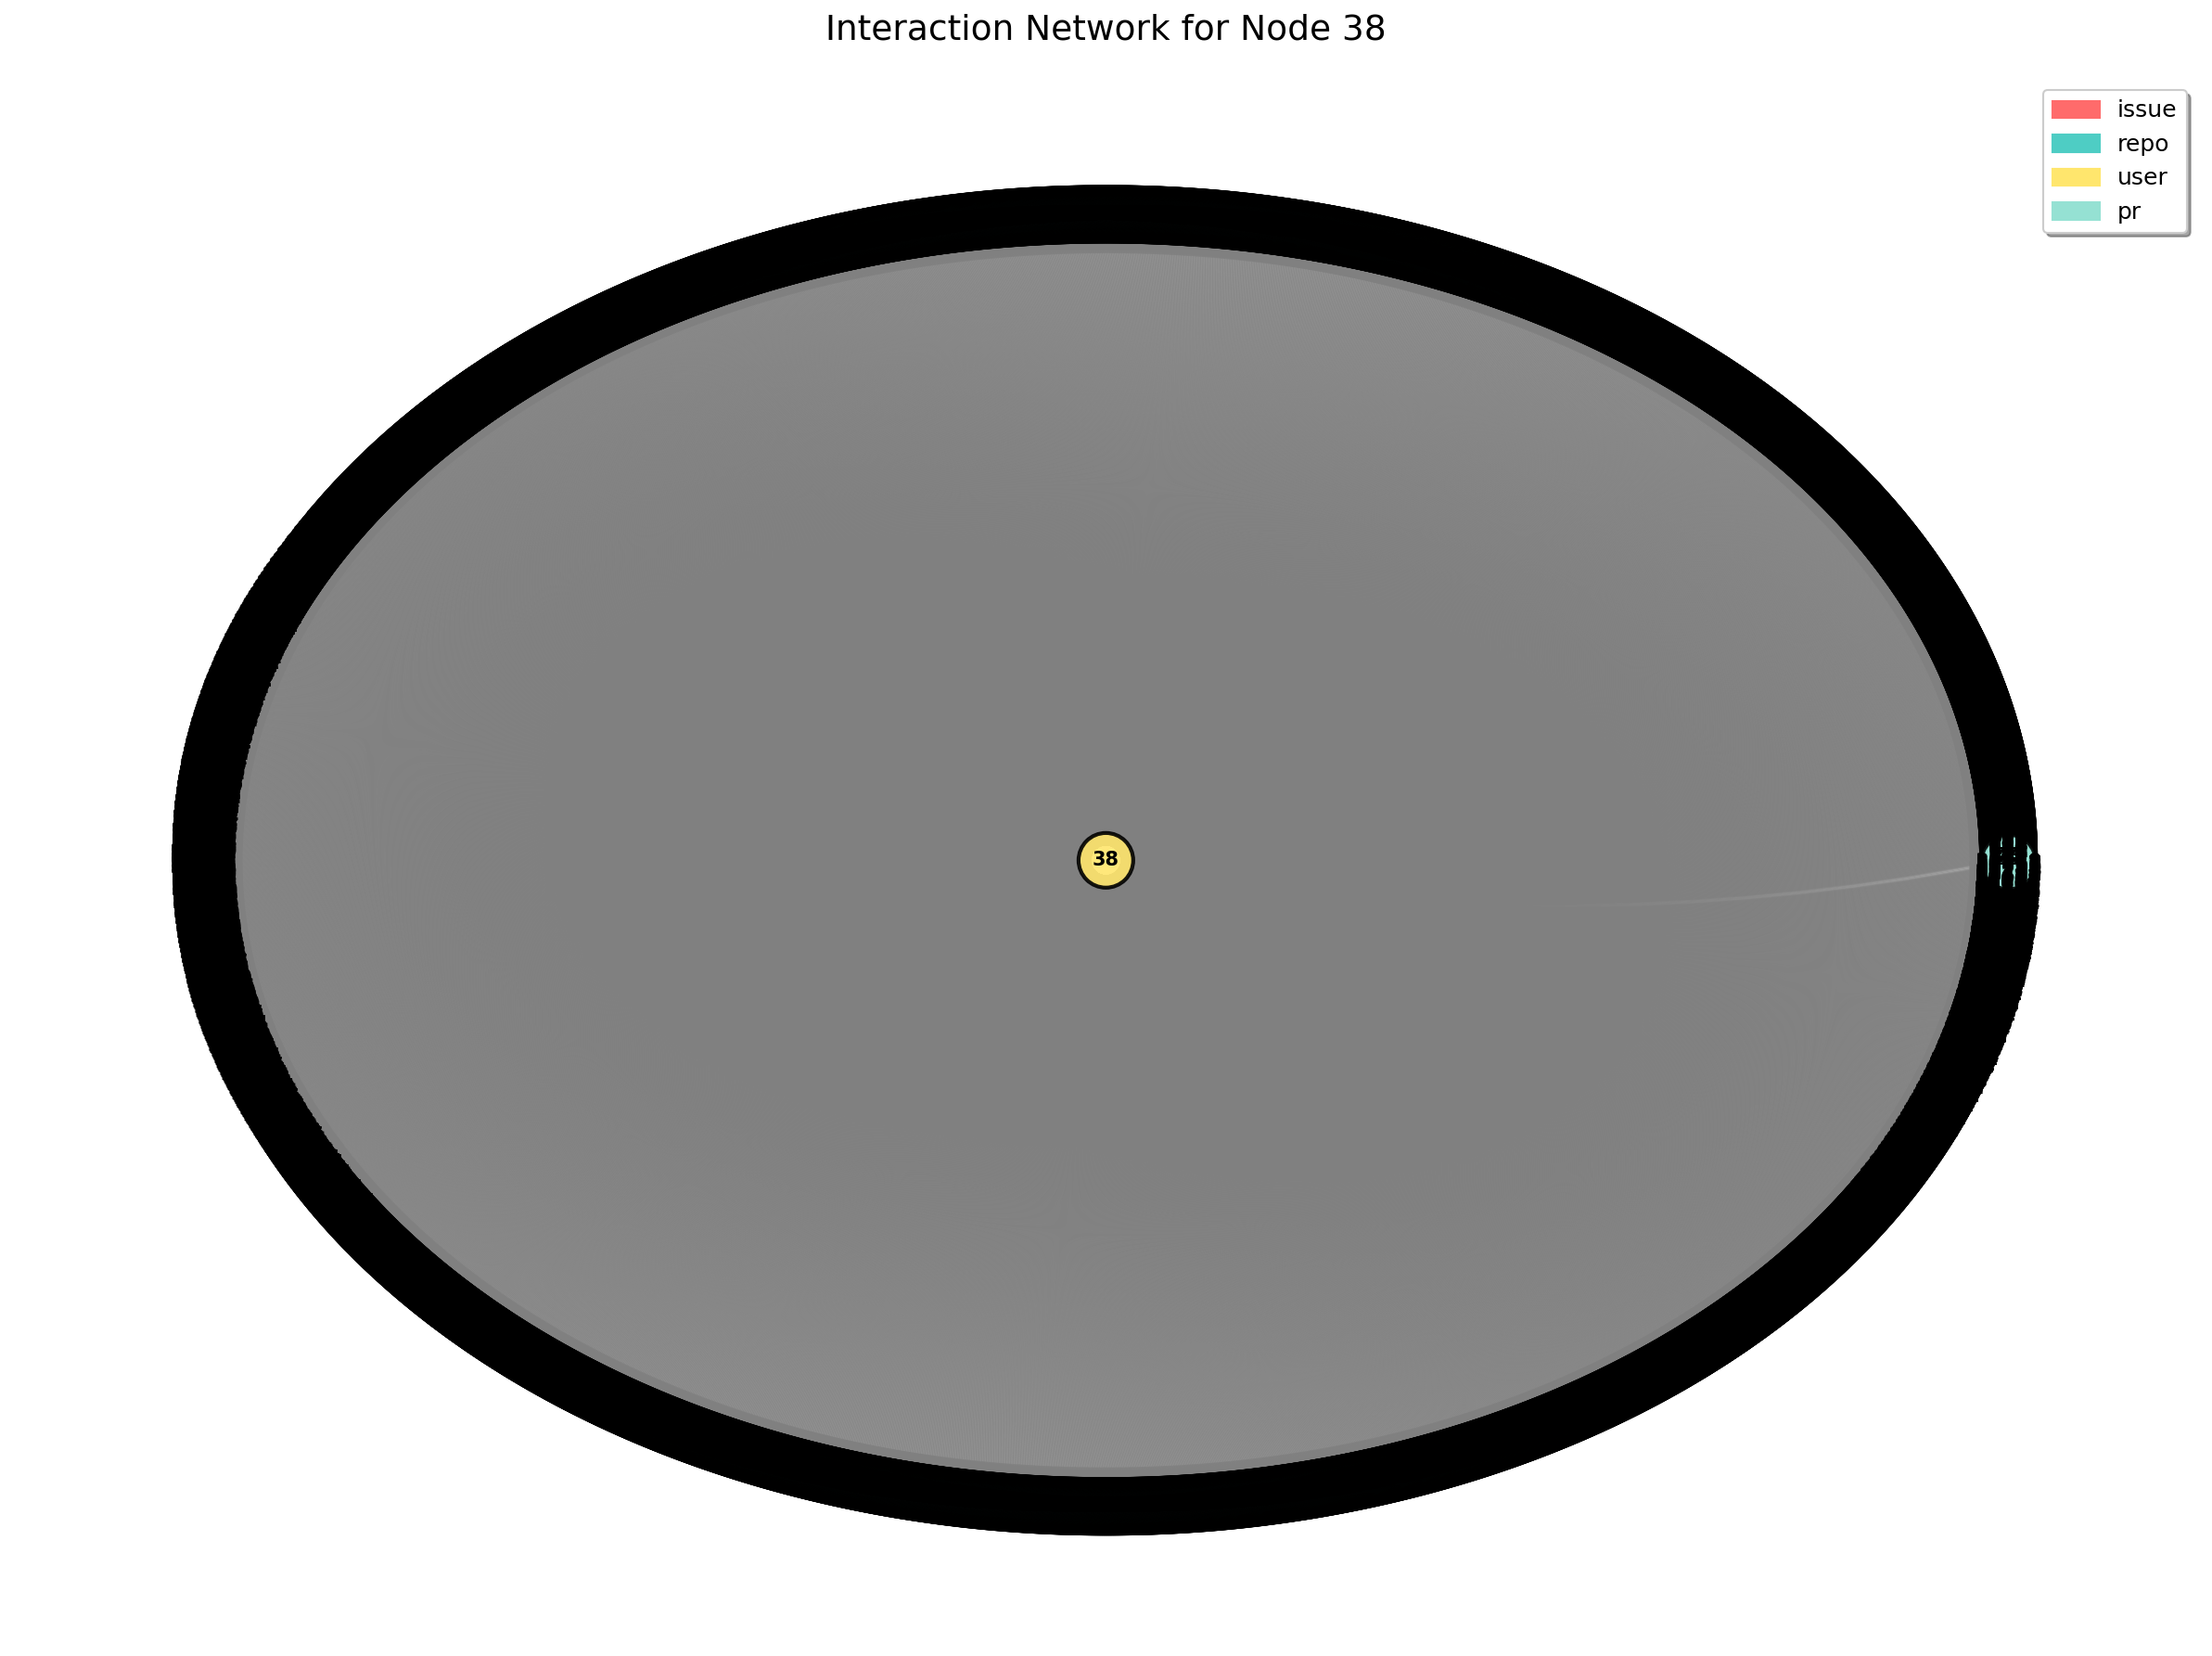

In [82]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 创建有向图
G = nx.DiGraph()

# 添加边和节点（自动添加节点）
for _, row in df_edges_single.iterrows():
    G.add_edge(row["src"], row["dst"], relation=row["rel"], timestamp=row["ts"])
    # 存储节点类型信息
    G.nodes[row["src"]]["type"] = row["src_type_str"]
    G.nodes[row["dst"]]["type"] = row["dst_type_str"]

# 准备绘图
plt.figure(figsize=(16, 12), dpi=150)

# 布局算法（可以尝试不同的布局）
# pos = nx.spring_layout(G, k=2, iterations=50, seed=42)  # 力导向布局
pos = nx.kamada_kawai_layout(G)  # Kamada-Kawai布局（更稳定）

# 按类型分组节点
node_colors = [node_type_colors[G.nodes[node]["type"]] for node in G.nodes()]

# 绘制节点
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=800,
    alpha=0.9,
    edgecolors="black",
    linewidths=2,
)

# 绘制边
nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    arrows=True,
    arrowsize=20,
    arrowstyle="->",
    width=2,
    alpha=0.6,
    connectionstyle="arc3,rad=0.1",  # 弯曲的边，避免重叠
)

# 绘制节点标签
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", font_color="black")

# 创建图例
legend_elements = [
    mpatches.Patch(color=color, label=node_type, edgecolor="black", linewidth=1.5)
    for node_type, color in node_type_colors.items()
]
plt.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
)

plt.title(f"Interaction Network for Node {node_id}", fontsize=18, pad=20)
plt.axis("off")
plt.tight_layout()
plt.savefig(
    f"aux-exp/RQ6/data/node_{node_id}_network.png", dpi=300, bbox_inches="tight"
)
print(f"✅ 静态网络图已保存: aux-exp/RQ6/data/node_{node_id}_network.png")
plt.show()